# Metric — Multiple-Choice Success Rate (letter-scoring variant)

$$\mathrm{Acc} = \frac{1}{N}\sum_{i} \mathbf{1}\!\left[\hat{a}_i = y^{+}_i\right]$$

**Not the multiple-choice metric reported in the thesis.** With `CHOICE_METHOD = "letter_logprob"` this scores each option by the log-probability of its **option letter** (A/B/C/D) rather than of the answer text. A `generate`-based scorer is also present and selectable.

For the metric defined in the thesis — length-normalised log-likelihood of the answer itself — use `mc_choice_answer_logprob.ipynb`.

---

*Notation:* `q` query · `c+` relevant snippet · `c-` off-topic snippet from the same user · `y+` personalised answer · `y-` general answer


In [1]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !pip -q install -U datasets huggingface_hub transformers accelerate peft bitsandbytes matplotlib

    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_ROOT = Path("/content/drive/MyDrive")
else:
    DRIVE_ROOT = Path(".")

if IN_COLAB:
    PP_ROOT = DRIVE_ROOT / "privacy_perserving_pllm"
else:
    _here = Path(".").resolve()
    PP_ROOT = next(
        (
            p for p in [_here, *_here.parents]
            if (p / "v2_personamem_persona_subsets").exists()
            or all((p / d).exists() for d in ("centralised", "evaluation", "fed_grad_avg", "zero_shot"))
        ),
        _here,
    )
SUBSET_NAME = "subset_0"
SUBSETS_DIR = PP_ROOT / "v2_personamem_persona_subsets"

OUTPUT_DIR = PP_ROOT / SUBSET_NAME / "v2_personamem_mc_choice_eval"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Subset:", SUBSET_NAME)
print("MC results will be saved to:", OUTPUT_DIR.resolve())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 765.1/765.1 kB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 139.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 153.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 52.2 MB/s eta 0:00:00
Mounted at /content/drive
Subset: subset_0
MC results will be saved to: /content/drive/MyDrive/privacy_perserving_pllm/subset_0/v2_personamem_mc_choice_eval


In [2]:
import ast
import json
import random
from typing import Any, Dict, List

import pandas as pd
from transformers import AutoTokenizer

SEED = 42
random.seed(SEED)


def parse_user_query(raw):
    if isinstance(raw, dict):
        return str(raw.get("content", raw)).strip()
    if isinstance(raw, str):
        try:
            d = ast.literal_eval(raw)
            if isinstance(d, dict):
                return str(d.get("content", raw)).strip()
        except (ValueError, SyntaxError):
            pass
        return raw.strip()
    return str(raw).strip()


def parse_incorrect_answers(raw):
    if isinstance(raw, list):
        return [str(x) for x in raw]
    if hasattr(raw, "tolist"):
        return [str(x) for x in raw.tolist()]
    if isinstance(raw, str):
        try:
            val = ast.literal_eval(raw)
            if isinstance(val, list):
                return [str(x) for x in val]
        except (ValueError, SyntaxError):
            pass
        return [raw]
    return []


def get_snippet(row):
    val = row.get("related_conversation_snippet")
    if val is None:
        return ""
    return str(val).strip()

In [3]:
def load_subset(name, subsets_dir=SUBSETS_DIR):
    """Load a persona subset (ids + train/val rows) saved by create_persona_subsets.ipynb."""
    subset_dir = Path(subsets_dir) / name
    if not subset_dir.exists():
        raise FileNotFoundError(f"Subset not found: {subset_dir}. Run create_persona_subsets.ipynb first.")
    with open(subset_dir / "personas.json", "r", encoding="utf-8") as f:
        persona_ids = [int(p) for p in json.load(f)]
    tr = pd.read_parquet(subset_dir / "train.parquet")
    va = pd.read_parquet(subset_dir / "val.parquet")
    return sorted(persona_ids), tr, va


CLIENT_PERSONAS, train_df, val_df = load_subset(SUBSET_NAME)
NUM_CLIENTS = len(CLIENT_PERSONAS)
print(f"Subset '{SUBSET_NAME}': {NUM_CLIENTS} personas | val rows: {len(val_df):,}")

Subset 'subset_0': 50 personas | val rows: 230


In [4]:
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc

import torch
from peft import PeftModel
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
MAX_SNIPPET_TOKENS = 1024

model_tok = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if model_tok.pad_token is None:
    model_tok.pad_token = model_tok.eos_token
model_tok.padding_side = "left"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

MC_SYSTEM_PROMPT = (
    "You are selecting the response that THIS specific user would most prefer, based on the "
    "relevant conversation snippet. You are given a question and several candidate responses "
    "labelled with letters. Choose the single best option and reply with only that letter."
)

def truncate_snippet(snippet, max_tokens):
    ids = model_tok(snippet, add_special_tokens=False)["input_ids"]
    if len(ids) <= max_tokens:
        return snippet
    return model_tok.decode(ids[-max_tokens:], skip_special_tokens=True)

def build_mc_messages(row, options):
    lines = "\n".join(f"{letter}. {text}" for letter, text in options)
    user = (
        "Relevant snippet from our earlier conversation:\n"
        f"{truncate_snippet(get_snippet(row), MAX_SNIPPET_TOKENS)}\n\n"
        f"{parse_user_query(row['user_query'])}\n\n"
        "Which of the following responses would this user most prefer?\n"
        f"{lines}\n\n"
        "Answer with only the letter of the best option."
    )
    return [
        {"role": "system", "content": MC_SYSTEM_PROMPT},
        {"role": "user", "content": user},
    ]

def load_model(adapter_dir=None):
    """adapter_dir=None -> zero-shot base model; else base model + LoRA adapter."""
    base = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, quantization_config=bnb_config, device_map="auto",
        trust_remote_code=True, attn_implementation="sdpa",
    )
    base.config.use_cache = True
    model = base if adapter_dir is None else PeftModel.from_pretrained(base, str(adapter_dir))
    model.eval()
    return model

def free_model(model):
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [5]:
MODELS_TO_EVAL = {
    "zero_shot":       None,
    "centralized_sft":  PP_ROOT / SUBSET_NAME / "v2_personamem_centralized_sft_snippet"  / "global" / "adapter",
    "federated_sft":    PP_ROOT / SUBSET_NAME / "v2_personamem_federated_sft_snippet"    / "global" / "adapter",
    "centralized_orpo": PP_ROOT / SUBSET_NAME / "v2_personamem_centralized_orpo_snippet" / "global" / "adapter",
    "federated_orpo":   PP_ROOT / SUBSET_NAME / "v2_personamem_federated_orpo_snippet"   / "global" / "adapter",
}

MAX_OPTIONS = 4
CHOICE_METHOD = "letter_logprob"
EVAL_BATCH_SIZE = 16

LETTERS = [chr(ord("A") + i) for i in range(MAX_OPTIONS)]
print("Letters:", LETTERS, "| choice method:", CHOICE_METHOD)
print("Models:", list(MODELS_TO_EVAL))

Letters: ['A', 'B', 'C', 'D'] | choice method: letter_logprob
Models: ['zero_shot', 'centralized_sft', 'federated_sft', 'centralized_orpo', 'federated_orpo']


In [6]:
_rng = random.Random(SEED)
MC_ITEMS: List[Dict[str, Any]] = []
skipped = 0
for pid in CLIENT_PERSONAS:
    p_val = val_df[val_df["persona_id"] == pid].reset_index(drop=True)
    for ex_id, r in p_val.iterrows():
        row = r.to_dict()
        correct = str(row.get("correct_answer", "")).strip()
        incs = [s.strip() for s in parse_incorrect_answers(row.get("incorrect_answers")) if str(s).strip()]
        incs = [s for s in incs if s != correct][: MAX_OPTIONS - 1]
        if not correct or not incs:
            skipped += 1
            continue
        texts = [correct] + incs
        _rng.shuffle(texts)
        letters = LETTERS[: len(texts)]
        correct_letter = letters[texts.index(correct)]
        MC_ITEMS.append({
            "persona_id": int(pid),
            "ex_id": int(ex_id),
            "row": row,
            "options": list(zip(letters, texts)),
            "correct_letter": correct_letter,
            "num_options": len(texts),
        })

print(f"Built {len(MC_ITEMS)} MC items (skipped {skipped} with no distractors).")
opt_counts = pd.Series([it["num_options"] for it in MC_ITEMS]).value_counts().sort_index()
print("Options-per-question distribution:", dict(opt_counts))
print("Random-guess baseline (mean 1/num_options):",
      round(float(pd.Series([1.0 / it["num_options"] for it in MC_ITEMS]).mean()), 4))

Built 230 MC items (skipped 0 with no distractors).
Options-per-question distribution: {4: np.int64(230)}
Random-guess baseline (mean 1/num_options): 0.25


In [7]:
from tqdm.auto import tqdm

LETTER_CAND_IDS: Dict[str, List[int]] = {}
for L in LETTERS:
    ids = []
    for form in (L, " " + L):
        toks = model_tok(form, add_special_tokens=False)["input_ids"]
        if toks:
            ids.append(toks[0])
    LETTER_CAND_IDS[L] = sorted(set(ids))

import numpy as np

ALL_LETTER_IDS = {i for ids in LETTER_CAND_IDS.values() for i in ids}

def _rankdata_avg(a):
    a = np.asarray(a, dtype=float)
    order = a.argsort(kind="mergesort")
    ranks = np.empty(len(a), dtype=float)
    sa = a[order]
    i = 0
    while i < len(a):
        j = i
        while j + 1 < len(a) and sa[j + 1] == sa[i]:
            j += 1
        ranks[order[i:j + 1]] = (i + j) / 2.0 + 1.0
        i = j + 1
    return ranks

def auroc(pos, neg):
    """AUROC = P(random positive scores higher than random negative), tie-aware."""
    pos = np.asarray(pos, dtype=float); neg = np.asarray(neg, dtype=float)
    pos = pos[~np.isnan(pos)]; neg = neg[~np.isnan(neg)]
    n1, n2 = len(pos), len(neg)
    if n1 == 0 or n2 == 0:
        return float("nan")
    r = _rankdata_avg(np.concatenate([pos, neg]))
    return float((r[:n1].sum() - n1 * (n1 + 1) / 2.0) / (n1 * n2))

def expected_calibration_error(conf, correct, n_bins=10):
    conf = pd.to_numeric(pd.Series(conf), errors="coerce").values
    correct = np.asarray(correct, dtype=float)
    mask = ~np.isnan(conf)
    conf, correct = conf[mask], correct[mask]
    if len(conf) == 0:
        return float("nan")
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece, n = 0.0, len(conf)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        sel = (conf > lo) & (conf <= hi) if i > 0 else (conf >= lo) & (conf <= hi)
        if sel.sum() == 0:
            continue
        ece += (sel.sum() / n) * abs(correct[sel].mean() - conf[sel].mean())
    return float(ece)

@torch.no_grad()
def _score_batch_letter(model, messages_list, letters_list, correct_list):
    """One forward pass per batch. Returns per-item choice + token distribution/confidence stats."""
    prompts = [model_tok.apply_chat_template(m, tokenize=False, add_generation_prompt=True)
               for m in messages_list]
    inputs = model_tok(prompts, return_tensors="pt", add_special_tokens=False, padding=True).to(model.device)
    logits = model(**inputs).logits[:, -1, :].float()
    probs_full = torch.softmax(logits, dim=-1)
    full_top1 = probs_full.max(dim=-1).values
    full_entropy = -(probs_full * torch.log(probs_full.clamp_min(1e-12))).sum(dim=-1)
    top1_ids = probs_full.argmax(dim=-1)

    out = []
    for b, (letters, correct_letter) in enumerate(zip(letters_list, correct_list)):
        letter_logit = [max(float(logits[b, tid]) for tid in LETTER_CAND_IDS[L]) for L in letters]
        opt = torch.softmax(torch.tensor(letter_logit), dim=-1)
        probs = {L: float(opt[k]) for k, L in enumerate(letters)}
        pred = max(probs, key=probs.get)
        ordered = sorted(probs.values(), reverse=True)
        margin = ordered[0] - (ordered[1] if len(ordered) > 1 else 0.0)
        entropy = float(-(opt * torch.log(opt.clamp_min(1e-12))).sum())
        out.append({
            "pred_letter": pred,
            "p_chosen": probs[pred],
            "p_correct": probs.get(correct_letter, float("nan")),
            "letter_margin": margin,
            "letter_entropy": entropy,
            "full_top1_prob": float(full_top1[b]),
            "full_entropy": float(full_entropy[b]),
            "is_letter_top1": bool(int(top1_ids[b]) in ALL_LETTER_IDS),
            "option_probs": json.dumps(probs),
        })
    return out

@torch.no_grad()
def _score_batch_generate(model, messages_list, letters_list, correct_list):
    prompts = [model_tok.apply_chat_template(m, tokenize=False, add_generation_prompt=True)
               for m in messages_list]
    inputs = model_tok(prompts, return_tensors="pt", add_special_tokens=False, padding=True).to(model.device)
    out_ids = model.generate(**inputs, max_new_tokens=4, do_sample=False, pad_token_id=model_tok.eos_token_id)
    new_tokens = out_ids[:, inputs["input_ids"].shape[1]:]
    texts = [model_tok.decode(g, skip_special_tokens=True) for g in new_tokens]
    out = []
    for text, letters in zip(texts, letters_list):
        pred = next((ch.upper() for ch in text if ch.upper() in letters), letters[0])
        out.append({
            "pred_letter": pred, "p_chosen": float("nan"), "p_correct": float("nan"),
            "letter_margin": float("nan"), "letter_entropy": float("nan"),
            "full_top1_prob": float("nan"), "full_entropy": float("nan"),
            "is_letter_top1": float("nan"), "option_probs": "{}",
        })
    return out

def score_batch(model, messages_list, letters_list, correct_list):
    if CHOICE_METHOD == "generate":
        return _score_batch_generate(model, messages_list, letters_list, correct_list)
    return _score_batch_letter(model, messages_list, letters_list, correct_list)

def evaluate_model(name, adapter):
    model = load_model(adapter)
    model.eval()
    model.config.use_cache = True
    model_tok.padding_side = "left"
    records = []
    for start in tqdm(range(0, len(MC_ITEMS), EVAL_BATCH_SIZE), desc=name):
        batch = MC_ITEMS[start:start + EVAL_BATCH_SIZE]
        msgs = [build_mc_messages(it["row"], it["options"]) for it in batch]
        letters = [[L for L, _ in it["options"]] for it in batch]
        correct = [it["correct_letter"] for it in batch]
        stats = score_batch(model, msgs, letters, correct)
        for it, s in zip(batch, stats):
            records.append({
                "model": name,
                "persona_id": it["persona_id"],
                "ex_id": it["ex_id"],
                "num_options": it["num_options"],
                "correct_letter": it["correct_letter"],
                "correct": bool(s["pred_letter"] == it["correct_letter"]),
                **s,
            })
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    free_model(model)
    return pd.DataFrame(records)

In [8]:
all_preds = []
summary_rows = []
per_persona_rows = []

for name, adapter in MODELS_TO_EVAL.items():
    if adapter is not None and not Path(adapter).exists():
        print(f"[skip] {name}: adapter not found at {adapter}")
        continue
    print(f"\n=== {name} (adapter={adapter}) ===")
    df = evaluate_model(name, adapter)
    all_preds.append(df)

    model_dir = OUTPUT_DIR / name
    model_dir.mkdir(parents=True, exist_ok=True)
    df.to_csv(model_dir / "mc_predictions.csv", index=False)

    success = float(df["correct"].mean())
    corr = df["correct"].values.astype(bool)

    def _m(series):
        return float(pd.to_numeric(series, errors="coerce").mean())

    conf_correct = _m(df.loc[corr, "p_chosen"]) if corr.any() else float("nan")
    conf_wrong = _m(df.loc[~corr, "p_chosen"]) if (~corr).any() else float("nan")
    summary_rows.append({
        "model": name,
        "n": int(len(df)),
        "success_rate": success,
        "random_baseline": float((1.0 / df["num_options"]).mean()),
        "mean_p_correct": _m(df["p_correct"]),
        "mean_p_chosen": _m(df["p_chosen"]),
        "mean_letter_margin": _m(df["letter_margin"]),
        "mean_letter_entropy": _m(df["letter_entropy"]),
        "conf_when_correct": conf_correct,
        "conf_when_wrong": conf_wrong,
        "conf_gap": conf_correct - conf_wrong,
        "auroc_conf_vs_correct": auroc(df.loc[corr, "p_chosen"].values, df.loc[~corr, "p_chosen"].values),
        "ece": expected_calibration_error(df["p_chosen"], df["correct"]),
        "mean_full_top1_prob": _m(df["full_top1_prob"]),
        "mean_full_entropy": _m(df["full_entropy"]),
        "frac_letter_is_top1": _m(df["is_letter_top1"]),
    })

    pp = df.groupby("persona_id")["correct"].mean().reset_index()
    pp = pp.rename(columns={"correct": "success_rate"})
    pp["model"] = name
    pp.to_csv(model_dir / "per_persona_success.csv", index=False)
    per_persona_rows.append(pp)

    print(f"  success rate: {success:.4f}  (n={len(df)})")

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUTPUT_DIR / "success_rate_summary.csv", index=False)
summary_df.to_json(OUTPUT_DIR / "success_rate_summary.json", orient="records", indent=2)
if all_preds:
    pd.concat(all_preds, ignore_index=True).to_csv(OUTPUT_DIR / "all_mc_predictions.csv", index=False)
if per_persona_rows:
    pd.concat(per_persona_rows, ignore_index=True).to_csv(OUTPUT_DIR / "per_persona_success_all_models.csv", index=False)

with open(OUTPUT_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump({
        "method": "mc_choice_success_rate",
        "subset": SUBSET_NAME,
        "split": "val",
        "choice_method": CHOICE_METHOD,
        "max_options": MAX_OPTIONS,
        "n_items": len(MC_ITEMS),
        "models": list(MODELS_TO_EVAL),
        "seed": SEED,
    }, f, indent=2)

print("\n=== Success rate (val, subset_0) ===")
print(summary_df.to_string(index=False))


=== zero_shot (adapter=None) ===


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

...

  success rate: 0.3652  (n=230)

=== federated_orpo (adapter=/content/drive/MyDrive/privacy_perserving_pllm/subset_0/v2_personamem_federated_orpo_snippet/global/adapter) ===


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


federated_orpo:   0%|          | 0/15 [00:00<?, ?it/s]

  success rate: 0.3652  (n=230)

=== Success rate (val, subset_0) ===
           model   n  success_rate  random_baseline  mean_p_correct  mean_p_chosen  mean_letter_margin  mean_letter_entropy  conf_when_correct  conf_when_wrong  conf_gap  auroc_conf_vs_correct      ece  mean_full_top1_prob  mean_full_entropy  frac_letter_is_top1
       zero_shot 230      0.382609             0.25        0.373180       0.775052            0.618208             0.579037           0.811175         0.752666  0.058509               0.594670 0.392444             0.774961           0.580368             1.000000
 centralized_sft 230      0.339130             0.25        0.334603       0.701085            0.503783             0.763138           0.727947         0.687301  0.040646               0.576501 0.361955             0.677032           0.925892             1.000000
   federated_sft 230      0.369565             0.25        0.329425       0.631679            0.412090             0.911323           0.64314

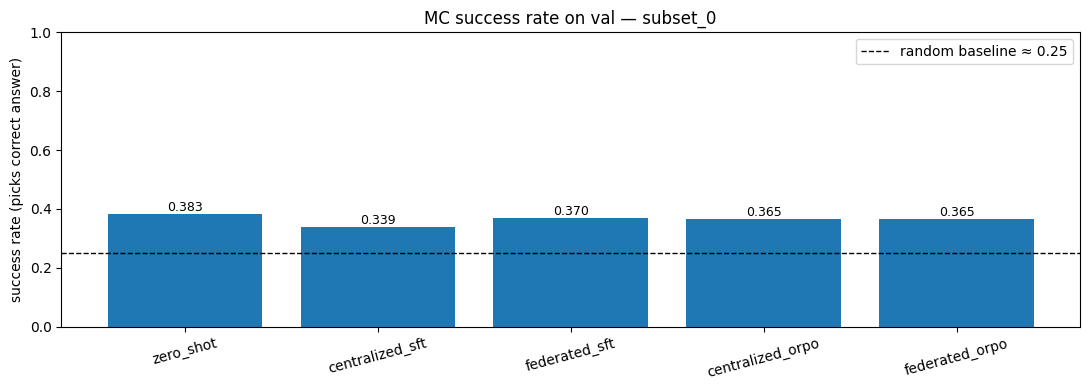

Saved: /content/drive/MyDrive/privacy_perserving_pllm/subset_0/v2_personamem_mc_choice_eval/fig_success_rate.png


In [9]:
import matplotlib.pyplot as plt

if len(summary_df):
    fig, ax = plt.subplots(figsize=(1.6 * len(summary_df) + 3, 4))
    bars = ax.bar(summary_df["model"], summary_df["success_rate"], color="tab:blue")
    base = float(summary_df["random_baseline"].mean())
    ax.axhline(base, color="k", ls="--", lw=1, label=f"random baseline ≈ {base:.2f}")
    ax.set_ylim(0, 1)
    ax.set_ylabel("success rate (picks correct answer)")
    ax.set_title(f"MC success rate on val — {SUBSET_NAME}")
    ax.tick_params(axis="x", rotation=15)
    for b, v in zip(bars, summary_df["success_rate"]):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig_success_rate.png", dpi=150)
    plt.show()
    print("Saved:", OUTPUT_DIR / "fig_success_rate.png")
else:
    print("No models were evaluated (check adapter paths in MODELS_TO_EVAL).")

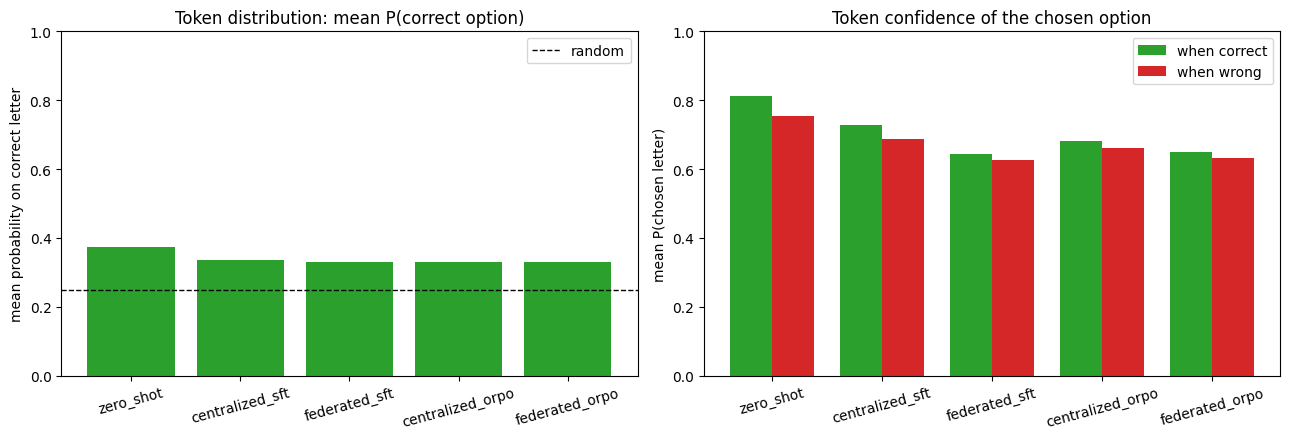

Saved: /content/drive/MyDrive/privacy_perserving_pllm/subset_0/v2_personamem_mc_choice_eval/fig_token_confidence.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np

if len(summary_df):
    S = summary_df
    x = np.arange(len(S)); w = 0.38
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

    ax[0].bar(S["model"], S["mean_p_correct"], color="tab:green")
    ax[0].axhline(float(S["random_baseline"].mean()), color="k", ls="--", lw=1, label="random")
    ax[0].set_ylim(0, 1)
    ax[0].set_title("Token distribution: mean P(correct option)")
    ax[0].set_ylabel("mean probability on correct letter")
    ax[0].tick_params(axis="x", rotation=15); ax[0].legend()

    ax[1].bar(x - w / 2, S["conf_when_correct"], w, label="when correct", color="tab:green")
    ax[1].bar(x + w / 2, S["conf_when_wrong"], w, label="when wrong", color="tab:red")
    ax[1].set_xticks(x); ax[1].set_xticklabels(S["model"], rotation=15)
    ax[1].set_ylim(0, 1)
    ax[1].set_title("Token confidence of the chosen option")
    ax[1].set_ylabel("mean P(chosen letter)"); ax[1].legend()

    fig.tight_layout(); fig.savefig(OUTPUT_DIR / "fig_token_confidence.png", dpi=150); plt.show()
    print("Saved:", OUTPUT_DIR / "fig_token_confidence.png")

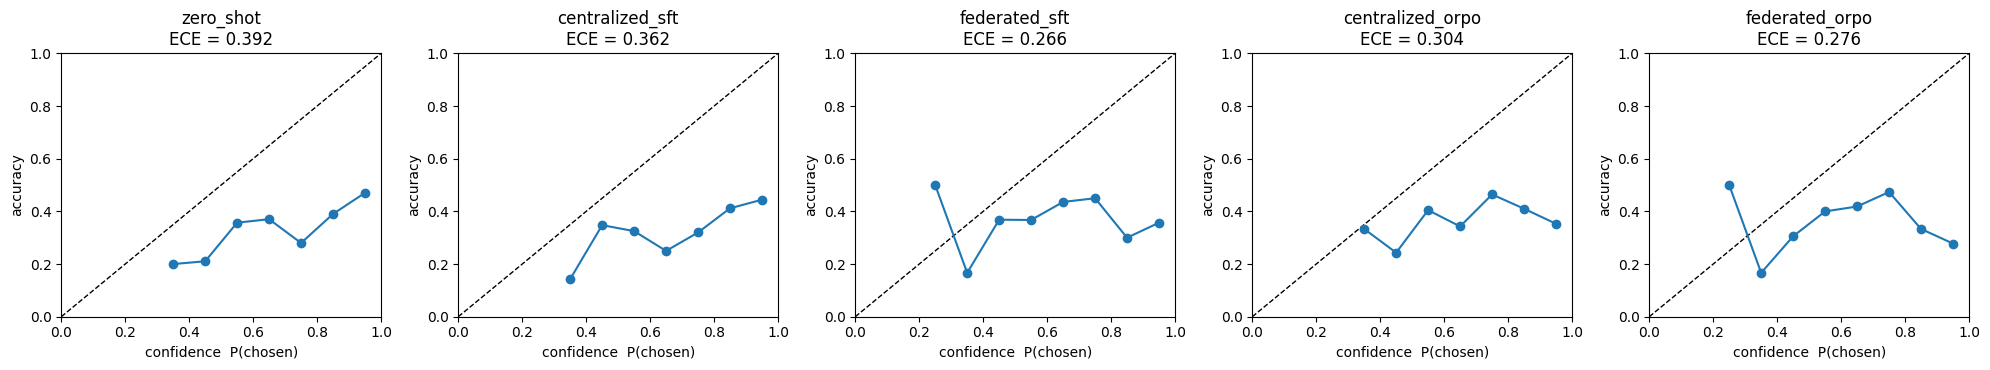

Saved: /content/drive/MyDrive/privacy_perserving_pllm/subset_0/v2_personamem_mc_choice_eval/fig_reliability.png


In [11]:
import matplotlib.pyplot as plt
import numpy as np

if all_preds:
    big = pd.concat(all_preds, ignore_index=True)
    models = [m for m in MODELS_TO_EVAL if (big["model"] == m).any()]
    n_bins = 10
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    centers = (bins[:-1] + bins[1:]) / 2
    ncol = max(1, len(models))
    fig, axes = plt.subplots(1, ncol, figsize=(4 * ncol, 3.8), squeeze=False)
    for j, m in enumerate(models):
        d = big[big["model"] == m]
        conf = pd.to_numeric(d["p_chosen"], errors="coerce").values
        corr = d["correct"].values.astype(float)
        accs = []
        for i in range(n_bins):
            lo, hi = bins[i], bins[i + 1]
            sel = (conf > lo) & (conf <= hi) if i > 0 else (conf >= lo) & (conf <= hi)
            accs.append(corr[sel].mean() if sel.sum() > 0 else np.nan)
        a = axes[0][j]
        a.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
        a.plot(centers, accs, marker="o", color="tab:blue")
        ece_val = float(summary_df.loc[summary_df["model"] == m, "ece"].iloc[0])
        a.set_title(f"{m}\nECE = {ece_val:.3f}")
        a.set_xlabel("confidence  P(chosen)"); a.set_ylabel("accuracy")
        a.set_xlim(0, 1); a.set_ylim(0, 1)
    fig.tight_layout(); fig.savefig(OUTPUT_DIR / "fig_reliability.png", dpi=150); plt.show()
    print("Saved:", OUTPUT_DIR / "fig_reliability.png")